# Model A — A0, A1 et A2 : diagnostic des features à date

Référence `foundation-v1`. Aucun modèle final ni prévision 2026. Les tables confidentielles restent en mémoire ; seules des statistiques agrégées sont affichées. Les prix effectifs, rent_position, concession_gap et historiques récents proposés dans le PDF ne sont **pas autorisés par la liste fermée** : ils restent différés, sans modification du contrat.

La sécurité temporelle repose sur les dates du bail connu et demeure conditionnelle à la fidélité de l'extrait CRM rétrospectif. Une association descriptive n'est pas un gain prédictif validé.

In [1]:
from pathlib import Path
import sys, hashlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.features.model_a_features import build_model_a_features, assert_foundation_reference, feature_screening, YEARS
from src.features.model_dataset import ADMISSIBLE_FEATURES, OCCURRENCE_FEATURES
protected=list((ROOT/'data/raw').glob('*.csv'))+[ROOT/'docs/modeling_contract.md']
protected+=list((ROOT/'notebooks').glob('0[1-5]_*.ipynb'))+[ROOT/'notebooks/starter.ipynb']
protected += [ROOT/p for p in ['src/same_unit.py','src/rent_economics.py','src/features/model_dataset.py','src/evaluation/backtest.py','src/external_data.py']]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
leases=pd.read_csv(ROOT/'data/raw/equinoxe_lease_history.csv',dtype={'sPropCode':'string','sUnitCode':'string'})
external=pd.read_csv(ROOT/'data/external/external_signals.csv')
display(assert_foundation_reference(leases))
for path in ['docs/modeling_contract.md','src/features/model_dataset.py','src/evaluation/backtest.py']:
    frozen=subprocess.run(['git','show',f'foundation-v1:{path}'],cwd=ROOT,capture_output=True,check=True).stdout
    assert frozen==(ROOT/path).read_bytes()
datasets={y:build_model_a_features(leases,y,include_targets=y<2026,external=external) for y in YEARS}
assert datasets[2026].labels is None
print('A0 réussi : cohortes, cutoffs et sources figées reproduits ; labels séparés ; aucune nouvelle feature hors contrat.')

,year,candidates,observed_units,prediction_origin
0,2023,405,401.0,2022-12-31
1,2024,645,634.0,2023-12-31
2,2025,856,773.0,2024-12-31
3,2026,931,NaN,2025-12-31


A0 réussi : cohortes, cutoffs et sources figées reproduits ; labels séparés ; aucune nouvelle feature hors contrat.


## A1 — Schéma, valeurs manquantes et cardinalité

13 features pour l'occurrence ; 12 pour la croissance, expiry_month étant réservé à l'occurrence. Quatre colonnes d'audit séparées, deux labels optionnels. Les manquants restent NaN ; aucune unité n'est supprimée pour une feature absente. Le contexte externe reste séparé, sans feature supplémentaire.

In [2]:
schema=[]
for year,d in datasets.items():
    for feature in d.X:
        schema.append({'year':year,'feature':feature,'type':str(d.X[feature].dtype),
            'manquants':int(d.X[feature].isna().sum()),'manquants_pct':100*d.X[feature].isna().mean(),
            'cardinalité':d.X[feature].nunique(dropna=True)})
display(pd.DataFrame(schema))
display(pd.DataFrame([{'year':y,'unités':len(d.X),'features_occurrence':d.X.shape[1],
    'features_growth':d.X_growth.shape[1],'colonnes_audit':d.audit.shape[1],
    'labels':0 if d.labels is None else d.labels.shape[1],
    'contexte_externe_lignes':len(d.external_context)} for y,d in datasets.items()]))

,year,feature,type,manquants,manquants_pct,cardinalité
0,2023,property_code,object,0,0.0,5
1,2023,building,object,0,0.0,3
2,2023,province,object,0,0.0,1
3,2023,bedrooms,int64,0,0.0,4
4,2023,bathrooms,float64,0,0.0,3
5,2023,sqft,int64,0,0.0,149
6,2023,floor,int64,0,0.0,26
7,2023,unit_subtype,object,0,0.0,4
8,2023,prior_contractual_rent,int64,0,0.0,264
9,2023,prior_term_months,float64,0,0.0,4


,year,unités,features_occurrence,features_growth,colonnes_audit,labels,contexte_externe_lignes
0,2023,405,13,12,4,2,0
1,2024,645,13,12,4,2,0
2,2025,856,13,12,4,2,0
3,2026,931,13,12,4,0,9


## A2 — Drift et plausibilité des variables disponibles

Comparer les cohortes ne signifie pas suivre un panel constant. L'arrivée de bâtiments change la composition. La hausse du loyer contractuel connu et la baisse de superficie peuvent être associées à ce mix ; aucune interprétation causale. 2026 ne contribue à aucune analyse de target.

,year,feature,médiane,Q05,Q95,minimum,maximum,non_finis
0,2023,bedrooms,2.0000,1.0000,2.0000,0.0,3.0000,0
1,2023,bathrooms,1.0000,1.0000,2.0000,1.0,3.0000,0
2,2023,sqft,1165.0000,550.0000,1431.0000,465.0,1905.0000,0
3,2023,floor,10.0000,3.0000,22.0000,1.0,27.0000,0
4,2023,prior_contractual_rent,1930.0000,997.0000,2795.0000,695.0,3555.0000,0
5,2023,prior_term_months,12.0000,12.0000,12.0000,5.9,23.9000,0
6,2023,months_since_known_start,5.4538,1.0185,11.0324,0.0,20.8953,0
7,2023,expiry_month,7.0000,2.0000,11.0000,1.0,12.0000,0
8,2024,bedrooms,2.0000,0.0000,2.0000,0.0,3.0000,0
9,2024,bathrooms,1.0000,1.0000,2.0000,1.0,3.0000,0


Composition agrégée : building


,2023,2024,2025,2026
building,,,,
Saint-Elzear,213,215,216,268
Daniel-Johnson,111,125,129,128
Levesque,81,82,82,75
Le Carlyle,0,127,180,180
The Met,0,96,120,121
Westpark,0,0,129,159


Composition agrégée : province


,2023,2024,2025,2026
province,,,,
Quebec,405,549,736,810
Ontario,0,96,120,121


...

,2023,2024,2025,2026
bedrooms,,,,
2,287,395,519,544
1,100,197,276,316
3,9,13,15,22
0,9,40,46,49


Composition agrégée : unit_subtype


,2023,2024,2025,2026
unit_subtype,,,,
2 Bed,287,395,519,544
1 Bed,100,197,276,316
3 Bed,9,13,15,22
Studio,9,40,46,49


Composition agrégée : expiry_month


,2023,2024,2025,2026
expiry_month,,,,
6,59,95,126,143
7,52,80,85,90
9,46,68,91,108
8,42,72,94,91
10,41,51,57,61
5,35,59,85,91
4,26,47,65,62
11,25,43,54,69
3,23,40,55,65


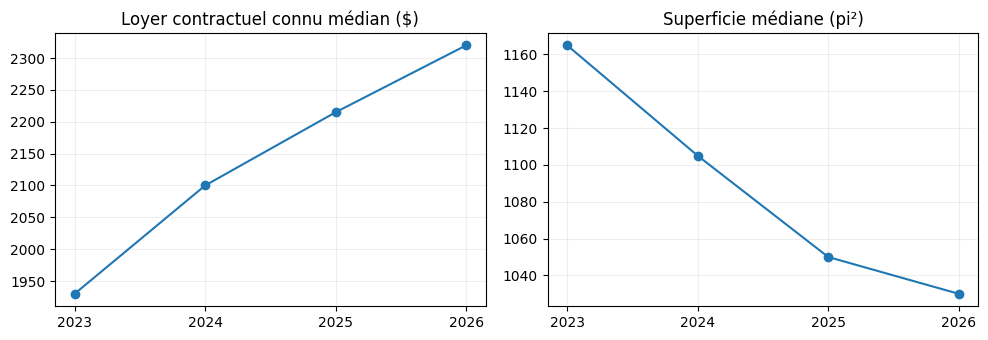

,year,loyers_contractuels_non_positifs,superficies_non_positives,mois_échéance_invalides,récence_négative
0,2023,0,0,0,0
1,2024,0,0,0,0
2,2025,0,0,0,0
3,2026,0,0,0,0


In [3]:
numeric=[f for f in datasets[2023].X.select_dtypes('number') if f!='forecast_year']
rows=[]
for year,d in datasets.items():
    for f in numeric:
        v=pd.to_numeric(d.X[f],errors='coerce')
        rows.append({'year':year,'feature':f,'médiane':v.median(),'Q05':v.quantile(.05),
            'Q95':v.quantile(.95),'minimum':v.min(),'maximum':v.max(),
            'non_finis':int((v.notna() & ~np.isfinite(v)).sum())})
display(pd.DataFrame(rows).round(4))
for feature in ['building','province','bedrooms','unit_subtype','expiry_month']:
    print('Composition agrégée :',feature)
    counts=pd.concat([d.X[feature].value_counts(dropna=False).rename(y) for y,d in datasets.items()],axis=1).fillna(0).astype(int)
    display(counts)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for ax,feature,title in zip(axes,['prior_contractual_rent','sqft'],['Loyer contractuel connu médian ($)','Superficie médiane (pi²)']):
    ax.plot(list(datasets),[d.X[feature].median() for d in datasets.values()],marker='o')
    ax.set_title(title);ax.set_xticks(list(datasets));ax.grid(alpha=.2)
plt.tight_layout();plt.show()
# Contrôles de plausibilité agrégés, sans suppression ni correction.
display(pd.DataFrame([{'year':y,'loyers_contractuels_non_positifs':int(d.X.prior_contractual_rent.le(0).sum()),
    'superficies_non_positives':int(d.X.sqft.le(0).sum()),
    'mois_échéance_invalides':int((~d.X.expiry_month.between(1,12)).sum()),
    'récence_négative':int(d.X.months_since_known_start.lt(0).sum())} for y,d in datasets.items()]))

## Occurrence : déséquilibre et segments

Statistiques ex post sur les labels de 2023–2025, sans prédicteur futur. Sous cinq unités, taux et statistiques sont masqués. Les petits nombres de non-transitions 2023–2024 interdisent de conclure à une règle stable. Les associations Saint-Elzear 2025 ne sont jamais présentées comme causales.

rent_position, concession_gap et history_available restent non construits : leur diagnostic prédictif n'est pas autorisé dans cette phase.

In [4]:
display(pd.DataFrame([{'year':y,'candidates':len(d.X),
    'occurrences':int(d.labels.transition_occurred.sum()),
    'non_occurrences':int(d.labels.transition_occurred.eq(0).sum()),
    'taux_pct':100*d.labels.transition_occurred.mean()} for y,d in datasets.items() if d.labels is not None]).round(3))
rare=[]
for year,d in datasets.items():
    if d.labels is None:continue
    work=pd.concat([d.X,d.labels],axis=1)
    for feature in ['building','province','expiry_month','bedrooms','unit_subtype']:
        grouped=work.groupby(feature,dropna=False).transition_occurred.agg(unités='size',occurrences='sum')
        grouped['taux_pct']=(100*grouped.occurrences/grouped.unités).where(grouped.unités.ge(5))
        print(year,feature);display(grouped.round(3))
        rare.append({'year':year,'feature':feature,'segments_moins_de_5':int(grouped.unités.lt(5).sum())})
    summary=work.groupby('transition_occurred')[numeric].median()
    support=work.groupby('transition_occurred').size()
    summary.loc[support.lt(5),:]=np.nan
    print('Médianes numériques par occurrence, petites classes masquées',year);display(summary.round(3))
display(pd.DataFrame(rare))

,year,candidates,occurrences,non_occurrences,taux_pct
0,2023,405,401,4,99.012
1,2024,645,634,11,98.295
2,2025,856,773,83,90.304


2023 building


,unités,occurrences,taux_pct
building,,,
Daniel-Johnson,111,110.0,99.099
Levesque,81,81.0,100.000
Saint-Elzear,213,210.0,98.592


2023 province


,unités,occurrences,taux_pct
province,,,
Quebec,405,401.0,99.012


...

2025 unit_subtype


,unités,occurrences,taux_pct
unit_subtype,,,
1 Bed,276,261.0,94.565
2 Bed,519,452.0,87.091
3 Bed,15,14.0,93.333
Studio,46,46.0,100.000


Médianes numériques par occurrence, petites classes masquées 2025


,bedrooms,bathrooms,sqft,floor,prior_contractual_rent,prior_term_months,months_since_known_start,expiry_month
transition_occurred,,,,,,,,
0.0,2.0,1.0,1195.0,9.0,2310.0,12.0,4.501,8.0
1.0,2.0,1.0,1020.0,7.0,2195.0,12.0,5.684,7.0


,year,feature,segments_moins_de_5
0,2023,building,0
1,2023,province,0
2,2023,expiry_month,0
3,2023,bedrooms,0
4,2023,unit_subtype,0
5,2024,building,0
6,2024,province,0
7,2024,expiry_month,0
8,2024,bedrooms,0
9,2024,unit_subtype,0


## Croissance conditionnelle : distribution et associations descriptives

G_i conserve la définition fondation : moyenne des croissances annualisées admissibles par unité si plusieurs transitions. Valeurs stockées en fractions, affichées en pourcentage. Aucun extrême retiré. Les minima/maxima sont des statistiques agrégées, aucun bail n'est affiché.

Les corrélations de rang sont calculées séparément par année, avec vingt couples complets minimum. Elles ne constituent ni une performance prédictive ni un critère automatique de sélection ; les futures décisions doivent se faire sur train seul.

In [5]:
growth=[];relations=[];extremes=[]
for year,d in datasets.items():
    if d.labels is None:continue
    work=pd.concat([d.X,d.labels],axis=1).loc[d.labels.transition_occurred.eq(1)].copy()
    v=100*work.conditional_growth
    growth.append({'year':year,'unités':len(v),'moyenne_pct':v.mean(),'médiane_pct':v.median(),
        'Q05_pct':v.quantile(.05),'Q95_pct':v.quantile(.95),'minimum_pct':v.min(),'maximum_pct':v.max()})
    q1,q3=v.quantile([.25,.75]);flag=v.lt(q1-3*(q3-q1))|v.gt(q3+3*(q3-q1))
    extremes.append({'year':year,'extrêmes_signalés_3IQR':int(flag.sum()),'supprimés':0})
    for f in numeric:
        pair=work[[f,'conditional_growth']].dropna()
        correlation=pair[f].rank().corr(pair.conditional_growth.rank()) if len(pair)>=20 and pair[f].nunique()>1 else np.nan
        relations.append({'year':year,'feature':f,'couples':len(pair),'association_rangs':correlation})
    for f in ['building','province','bedrooms','prior_term_months']:
        groups=work.groupby(f,dropna=False).conditional_growth.agg(unités='size',médiane='median',moyenne='mean')
        groups[['médiane','moyenne']]=100*groups[['médiane','moyenne']].where(groups.unités.ge(5),np.nan)
        print('Croissance par catégorie',year,f);display(groups.round(3))
display(pd.DataFrame(growth).round(3));display(pd.DataFrame(relations).round(3));display(pd.DataFrame(extremes))

Croissance par catégorie 2023 building


,unités,médiane,moyenne
building,,,
Daniel-Johnson,110,2.331,2.293
Levesque,81,2.097,2.381
Saint-Elzear,210,1.969,2.125


Croissance par catégorie 2023 province


,unités,médiane,moyenne
province,,,
Quebec,401,2.085,2.223


Croissance par catégorie 2023 bedrooms


...

Croissance par catégorie 2025 prior_term_months


,unités,médiane,moyenne
prior_term_months,,,
5.9,10,5.550,7.986
12.0,742,3.731,3.889
17.9,13,2.325,3.758
23.9,8,2.770,2.269


,year,unités,moyenne_pct,médiane_pct,Q05_pct,Q95_pct,minimum_pct,maximum_pct
0,2023,401,2.223,2.085,-5.534,10.200,-12.268,15.591
1,2024,634,1.921,1.700,-6.391,12.972,-9.334,26.974
2,2025,773,3.923,3.717,-5.730,16.129,-10.411,31.718


,year,feature,couples,association_rangs
0,2023,bedrooms,401,0.032
1,2023,bathrooms,401,0.088
2,2023,sqft,401,0.061
3,2023,floor,401,-0.011
4,2023,prior_contractual_rent,401,0.034
5,2023,prior_term_months,401,-0.083
6,2023,months_since_known_start,401,0.054
7,2023,expiry_month,401,-0.086
8,2024,bedrooms,634,-0.005
9,2024,bathrooms,634,-0.023


,year,extrêmes_signalés_3IQR,supprimés
0,2023,0,0
1,2024,1,0
2,2025,8,0


## Screening — recommandations sous contrat inchangé

Sens économique, redondance et support priment sur les corrélations. KEEP/OPTIONAL n'est pas une sélection finale apprise sur les années test. point_in_time_safe concerne le contrôle de cutoff, sous réserve de fidélité des champs CRM. Les familles différées apparaissent explicitement comme hors contrat, pas comme des colonnes imputées.

In [6]:
screening=feature_screening(datasets)
display(screening)
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==v for p,v in hashes.items())
print('Intégrité : fondation, données brutes et notebooks antérieurs inchangés. Aucun export CRM, entraînement final ni forecast 2026.')

,feature,type,available_rate,point_in_time_safe,candidate_for_occurrence,candidate_for_growth,recommendation,reason,warning
0,property_code,object,1.0,True,True,True,OPTIONAL,redondance/complexité à limiter,sécurité conditionnelle à la fidélité CRM ; re...
1,building,object,1.0,True,True,True,KEEP,sens structurel ou contractuel,sécurité conditionnelle à la fidélité CRM ; re...
2,province,object,1.0,True,True,True,KEEP,sens structurel ou contractuel,sécurité conditionnelle à la fidélité CRM ; re...
3,bedrooms,int64,1.0,True,True,True,KEEP,sens structurel ou contractuel,sécurité conditionnelle à la fidélité CRM ; re...
4,bathrooms,float64,1.0,True,True,True,OPTIONAL,redondance/complexité à limiter,sécurité conditionnelle à la fidélité CRM ; re...
5,sqft,int64,1.0,True,True,True,KEEP,sens structurel ou contractuel,sécurité conditionnelle à la fidélité CRM ; re...
6,floor,int64,1.0,True,True,True,OPTIONAL,redondance/complexité à limiter,sécurité conditionnelle à la fidélité CRM ; re...
7,unit_subtype,object,1.0,True,True,True,OPTIONAL,redondance/complexité à limiter,sécurité conditionnelle à la fidélité CRM ; re...
8,prior_contractual_rent,int64,1.0,True,True,True,KEEP,sens structurel ou contractuel,sécurité conditionnelle à la fidélité CRM ; re...
9,prior_term_months,float64,1.0,True,True,True,KEEP,sens structurel ou contractuel,sécurité conditionnelle à la fidélité CRM ; re...


Intégrité : fondation, données brutes et notebooks antérieurs inchangés. Aucun export CRM, entraînement final ni forecast 2026.


## Conclusions A0–A2

1. Cohortes et unités avec transition reproduites ; liste fermée, P1, fractions et cutoffs inchangés.
2. 13 features disponibles, aucune valeur manquante dans l'extrait courant ; 12 seulement autorisées pour growth. Les manquants synthétiques restent conservés sans retrait de candidat.
3. Drift descriptif : loyer contractuel médian 1 930 → 2 320 $, superficie médiane 1 165 → 1 030 pi² entre cohortes 2023 et 2026 ; les bâtiments/provinces disponibles changent aussi.
4. Occurrence : 99,012 → 98,295 → 90,304 %, avec concentration des absences à Saint-Elzear en 2025. Ce déséquilibre et les petits segments limitent la sélection descriptive.
5. G_i médian parmi candidates ayant une transition : environ 2,085 / 1,700 / 3,717 % ; extrêmes signalés, jamais supprimés. Les associations ne démontrent pas de gain hors échantillon.

Recommandations principales : building, province, bedrooms, sqft, prior_contractual_rent, prior_term_months et months_since_known_start ; expiry_month pour occurrence uniquement. property_code, bathrooms, floor, unit_subtype et forecast_year restent optionnels, avec encodage/choix à apprendre dans les folds.

Le PDF propose des features économiques absentes de l'autorisation du contrat ; elles nécessitent une décision explicite ultérieure, sans modification silencieuse ici. Le moteur restreint peut alimenter A3–A6 ; une prétention à Model A enrichi en rent_position/gap/historiques serait prématurée. Aucun forecast final 2026.

## A2.5 — Extension économique et historique

Extension expérimentale distincte de CORE et du contrat commun. Les trois features économiques courantes sont **NOT_IDENTIFIABLE** : la date de disponibilité de l'effectif courant manque ; aucun gap, ratio ou fallback n'est construit. Les quatre historiques sont **SAFE_WITH_CONDITIONS** : les paires sont formées après filtrage des baux connus, et leurs débuts, signatures et fins doivent être antérieurs ou égaux à D. Cette maturité conservatrice **ne prouve pas** la fidélité du snapshot CRM ni la date de calcul source.

Fenêtre récente unique (D−365 jours, D], minimum cinq transitions, sinon NaN. Aucun retrait d'extrême ni imputation. Les taux portent sur les unités de la cohorte ; une valeur portefeuille répétée n'est pas autant d'observations indépendantes. Les statistiques de moins de cinq valeurs sont masquées ; les associations exigent vingt paires et restent descriptives. Aucune cible ni prévision 2026.

In [7]:
from src.features.model_a_features import CORE_FEATURES, ENRICHED_FEATURES, EXPERIMENTAL_FEATURES, EXPERIMENT_SAFETY

enriched={y:build_model_a_features(leases,y,include_targets=y<2026,feature_set="enriched") for y in YEARS}
for y,d in enriched.items():
    pd.testing.assert_frame_equal(d.X[list(CORE_FEATURES)],datasets[y].X)
    pd.testing.assert_frame_equal(d.audit,datasets[y].audit)
    if y<2026: pd.testing.assert_frame_equal(d.labels,datasets[y].labels)
    else: assert d.labels is None
    assert len(d.X.columns)==17 and len(d.X_growth.columns)==16
display(pd.DataFrame([{'feature':f,'statut':status,'construite':f in EXPERIMENTAL_FEATURES} for f,status in EXPERIMENT_SAFETY.items()]))
print('CORE : 13 / 12 ; ENRICHED : 17 / 16. Cohortes et labels inchangés ; aucun label 2026.')


,feature,statut,construite
0,prior_effective_rent,NOT_IDENTIFIABLE,False
1,concession_gap,NOT_IDENTIFIABLE,False
2,rent_position,NOT_IDENTIFIABLE,False
3,previous_same_unit_growth,SAFE_WITH_CONDITIONS,True
4,unit_historical_median_growth,SAFE_WITH_CONDITIONS,True
5,recent_building_growth,SAFE_WITH_CONDITIONS,True
6,recent_portfolio_growth,SAFE_WITH_CONDITIONS,True


CORE : 13 / 12 ; ENRICHED : 17 / 16. Cohortes et labels inchangés ; aucun label 2026.


In [8]:
diagnostic=[]; associations=[]
for year,d in enriched.items():
    for f in EXPERIMENTAL_FEATURES:
        v=d.X[f].dropna()
        stats={'médiane_pct':np.nan,'q05_pct':np.nan,'q95_pct':np.nan,'minimum_pct':np.nan,'maximum_pct':np.nan,'extrêmes_3IQR':np.nan}
        if len(v)>=5:
            q1,q3=v.quantile([.25,.75]);iqr=q3-q1
            stats={'médiane_pct':100*v.median(),'q05_pct':100*v.quantile(.05),'q95_pct':100*v.quantile(.95),
                   'minimum_pct':100*v.min(),'maximum_pct':100*v.max(),
                   'extrêmes_3IQR':int(((v<q1-3*iqr)|(v>q3+3*iqr)).sum())}
        diagnostic.append({'année':year,'feature':f,'disponibilité_pct':100*d.X[f].notna().mean(),**stats})
        if d.labels is None: continue
        work=pd.concat([d.X[[f]],d.labels],axis=1)
        for occurrence,g in work.groupby('transition_occurred'):
            vals=g[f].dropna()
            associations.append({'année':year,'feature':f,'relation':'occurrence','groupe':int(occurrence),
                'support':len(vals),'médiane_pct':100*vals.median() if len(vals)>=5 else np.nan,'corrélation_rangs':np.nan})
        pairs=work.loc[work.transition_occurred.eq(1),[f,'conditional_growth']].dropna()
        corr=pairs[f].rank().corr(pairs.conditional_growth.rank()) if len(pairs)>=20 and pairs[f].nunique()>1 and pairs.conditional_growth.nunique()>1 else np.nan
        associations.append({'année':year,'feature':f,'relation':'croissance conditionnelle','groupe':np.nan,
            'support':len(pairs),'médiane_pct':np.nan,'corrélation_rangs':corr})
diagnostic=pd.DataFrame(diagnostic)
diagnostic['variation_médiane_points']=diagnostic.groupby('feature',sort=False)['médiane_pct'].diff()
display(diagnostic.round(3))
display(pd.DataFrame(associations).round(3))
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==v for p,v in hashes.items())
print('Contrôles finaux : intégrité conservée ; aucun export individuel, modèle ou forecast.')


,année,feature,disponibilité_pct,médiane_pct,q05_pct,q95_pct,minimum_pct,maximum_pct,extrêmes_3IQR,variation_médiane_points
0,2023,previous_same_unit_growth,86.173,3.547,-2.347,10.810,-6.887,22.239,1.0,NaN
1,2023,unit_historical_median_growth,86.173,3.087,-0.752,6.623,-3.458,14.623,1.0,NaN
2,2023,recent_building_growth,52.593,1.130,1.130,1.130,1.130,1.130,0.0,NaN
3,2023,recent_portfolio_growth,100.000,2.264,2.264,2.264,2.264,2.264,0.0,NaN
4,2024,previous_same_unit_growth,55.349,4.521,-2.346,12.455,-6.851,29.499,1.0,0.974
5,2024,unit_historical_median_growth,55.349,3.295,-0.292,7.773,-3.054,29.499,1.0,0.208
6,2024,recent_building_growth,52.713,-0.866,-0.866,2.233,-0.866,2.233,0.0,-1.996
7,2024,recent_portfolio_growth,100.000,1.133,1.133,1.133,1.133,1.133,0.0,-1.131
8,2025,previous_same_unit_growth,50.584,2.145,-5.653,10.924,-12.268,23.674,0.0,-2.376
9,2025,unit_historical_median_growth,50.584,3.018,-1.573,7.257,-12.227,23.674,9.0,-0.276


,année,feature,relation,groupe,support,médiane_pct,corrélation_rangs
0,2023,previous_same_unit_growth,occurrence,0.0,4,NaN,NaN
1,2023,previous_same_unit_growth,occurrence,1.0,345,3.551,NaN
2,2023,previous_same_unit_growth,croissance conditionnelle,NaN,345,NaN,0.055
3,2023,unit_historical_median_growth,occurrence,0.0,4,NaN,NaN
4,2023,unit_historical_median_growth,occurrence,1.0,345,3.087,NaN
5,2023,unit_historical_median_growth,croissance conditionnelle,NaN,345,NaN,0.020
6,2023,recent_building_growth,occurrence,0.0,3,NaN,NaN
7,2023,recent_building_growth,occurrence,1.0,210,1.130,NaN
8,2023,recent_building_growth,croissance conditionnelle,NaN,210,NaN,NaN
9,2023,recent_portfolio_growth,occurrence,0.0,4,NaN,NaN


Contrôles finaux : intégrité conservée ; aucun export individuel, modèle ou forecast.


### Constats A2.5 et décision

- Les historiques unitaires sont disponibles à 86,17 / 55,35 / 50,58 / 63,37 % ; aucun candidat n'est supprimé.
- Les médianes de previous_same_unit_growth sont environ 3,55 / 4,52 / 2,14 / 1,71 % ; celles de unit_historical_median_growth, 3,09 / 3,29 / 3,02 / 2,34 %. Le drift combine composition et maturité ; aucune causalité n'est déduite.
- recent_building_growth est entièrement absent en 2025 et 2026. recent_portfolio_growth est entièrement absent en 2025 et constant entre unités aux autres origines.
- La maturité des deux baux sélectionne un sous-ensemble restreint dans la fenêtre récente ; ses médianes ne décrivent pas toutes les transitions récentes.
- Les extrêmes sont seulement signalés ; les relations aux labels historiques ne constituent pas une sélection de modèle.
- APPROVE FOR A3-A6, **conditionnellement** : previous_same_unit_growth et unit_historical_median_growth, sous validation de fidélité CRM et traitement des NaN sur train. REJECT FOR A3-A6 : les trois features économiques non identifiables et les deux indicateurs récents insuffisamment soutenus.
- **NO-GO immédiat pour ENRICHED sans validation de fidélité historique** ; CORE reste inchangé. Cohortes 405/645/856/931, occurrences 401/634/773 ; aucune cible ou prévision 2026.
